# Phase 2: Feature Engineering & Exploratory Data Analysis
In this notebook, we transform our cleaned data into a format suitable for a Neural Network. 
Key objectives include:
* **Categorical Encoding**: Converting text-based cities and countries into numerical values.
* **Data Visualization**: Analyzing the distribution of temperatures across different geographic locations.
* **Data Persistence**: Saving the engineered dataset for the scaling and modeling phases.

### Step 1: Label Encoding Categorical Variables
Machine learning models require numerical input. Since our dataset contains text data for **City** and **Country**, we use the `LabelEncoder` from `scikit-learn`. 
- `le_city`: Encodes city names into unique integers.
- `le_country`: Encodes country names into unique integers.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 
# Load the dataset
file_path = '../01_Data/02_GlobalLandTemperatures_Cleaned.csv'
df = pd.read_csv(file_path)

le_city, le_country = LabelEncoder(), LabelEncoder()
df['City_Encoded'] = le_city.fit_transform(df['City'])
df['Country_Encoded'] = le_country.fit_transform(df['Country'])
print('Encoding completed successfully.')

Encoding completed successfully.


In [9]:
# --- COMPLETE ENCODING REFERENCE ---

# 1. Print all City Mappings
print("="*30)
print("   FULL CITY ENCODING LIST")
print("="*30)
# le_city.classes_ contains the names in order (0, 1, 2...)
for code, name in enumerate(le_city.classes_):
    print(f"Code {code:3} : {name}")



   FULL CITY ENCODING LIST
Code   0 : Abidjan
Code   1 : Addis Abeba
Code   2 : Ahmadabad
Code   3 : Aleppo
Code   4 : Alexandria
Code   5 : Ankara
Code   6 : Baghdad
Code   7 : Bangalore
Code   8 : Bangkok
Code   9 : Belo Horizonte
Code  10 : Berlin
Code  11 : Bogotá
Code  12 : Bombay
Code  13 : Brasília
Code  14 : Cairo
Code  15 : Calcutta
Code  16 : Cali
Code  17 : Cape Town
Code  18 : Casablanca
Code  19 : Changchun
Code  20 : Chengdu
Code  21 : Chicago
Code  22 : Chongqing
Code  23 : Dakar
Code  24 : Dalian
Code  25 : Dar Es Salaam
Code  26 : Delhi
Code  27 : Dhaka
Code  28 : Durban
Code  29 : Faisalabad
Code  30 : Fortaleza
Code  31 : Gizeh
Code  32 : Guangzhou
Code  33 : Harare
Code  34 : Harbin
Code  35 : Ho Chi Minh City
Code  36 : Hyderabad
Code  37 : Ibadan
Code  38 : Istanbul
Code  39 : Izmir
Code  40 : Jaipur
Code  41 : Jakarta
Code  42 : Jiddah
Code  43 : Jinan
Code  44 : Kabul
Code  45 : Kano
Code  46 : Kanpur
Code  47 : Karachi
Code  48 : Kiev
Code  49 : Kinshasa
Code  

In [10]:
# 2. Print all Country Mappings
print("\n" + "="*30)
print("   FULL COUNTRY ENCODING LIST")
print("="*30)
for code, name in enumerate(le_country.classes_):
    print(f"Code {code:2} : {name}")


   FULL COUNTRY ENCODING LIST
Code  0 : Afghanistan
Code  1 : Angola
Code  2 : Australia
Code  3 : Bangladesh
Code  4 : Brazil
Code  5 : Burma
Code  6 : Canada
Code  7 : Chile
Code  8 : China
Code  9 : Colombia
Code 10 : Congo (Democratic Republic Of The)
Code 11 : Côte D'Ivoire
Code 12 : Dominican Republic
Code 13 : Egypt
Code 14 : Ethiopia
Code 15 : France
Code 16 : Germany
Code 17 : India
Code 18 : Indonesia
Code 19 : Iran
Code 20 : Iraq
Code 21 : Italy
Code 22 : Japan
Code 23 : Kenya
Code 24 : Mexico
Code 25 : Morocco
Code 26 : Nigeria
Code 27 : Pakistan
Code 28 : Peru
Code 29 : Philippines
Code 30 : Russia
Code 31 : Saudi Arabia
Code 32 : Senegal
Code 33 : Singapore
Code 34 : Somalia
Code 35 : South Africa
Code 36 : South Korea
Code 37 : Spain
Code 38 : Sudan
Code 39 : Syria
Code 40 : Taiwan
Code 41 : Tanzania
Code 42 : Thailand
Code 43 : Turkey
Code 44 : Ukraine
Code 45 : United Kingdom
Code 46 : United States
Code 47 : Vietnam
Code 48 : Zimbabwe


### Step 2: Visualizing Global Temperature Trends
To understand our data better, we visualize the top 10 hottest countries based on their mean `AverageTemperature`. This helps us verify that the data reflects realistic global patterns before we move to model training.

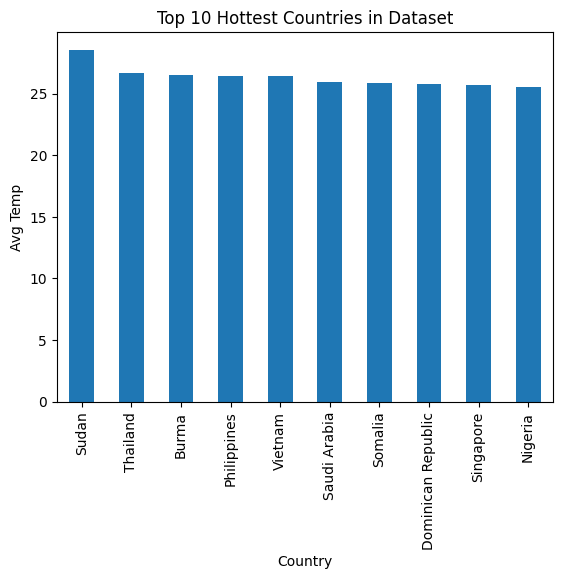

In [11]:
# Bar Chart of Top 10 Hottest Countries
top_10_countries = df.groupby('Country')['AverageTemperature'].mean().sort_values(ascending=False).head(10)
top_10_countries.plot(kind='bar')
plt.title('Top 10 Hottest Countries in Dataset')
plt.ylabel('Avg Temp')
plt.show()

### Step 3: Exporting Engineered Data
We now save the dataset as `03_GlobalLandTemperatures_encoded.csv`. This file contains the new `City_Encoded` and `Country_Encoded` columns which will be used as primary features in the next phase (Scaling).

In [12]:
# Save the updated data to a new CSV file
df.to_csv('../01_Data/03_GlobalLandTemperatures_encoded.csv', index=False)
print('Updated file saved successfully.')

Updated file saved successfully.
